# Cursos de Series de tiempo con *Machine Learning*
## Modulo. Supuesto 2: La Estacionariedad.
                        Elaborado por: Naren Castellon

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [35]:
df =  pd.read_csv('./ferreteria.csv', parse_dates= ['ds'])
df

,Unnamed: 0,sku_id,ds,price_unit,promotion_active,season_factor,temperature_avg,rain_days,events_nearby,marketing_spend,...,store_visits,holiday_week,new_product_launch,lead_time_days,current_stock,supplier_delay_rate,customer_reviews_score,distribution_channels,previous_sku,demand_units
0,0,Martillo 16oz,2021-01-04,59.31,0,1.620537,21.948085,3,1,4472.923246,...,12007,1,0,21,1092,0.195272,3.5,3,Martillo 16oz,760
1,1,Martillo 16oz,2021-01-11,142.85,1,1.739316,14.436052,2,0,5735.450391,...,12084,0,0,21,220,0.134813,3.9,2,Martillo 16oz,1069
2,2,Martillo 16oz,2021-01-18,111.14,0,1.854605,27.699857,5,1,3000.000000,...,11969,0,0,30,2324,0.167410,3.7,3,"Tubos PVC 1/2""",830
3,3,Martillo 16oz,2021-01-25,91.81,0,1.964723,22.893538,3,1,12230.349623,...,11860,0,0,30,3803,0.150220,4.8,3,Martillo 16oz,1153
4,4,Martillo 16oz,2021-02-01,27.62,1,2.068065,23.743801,3,1,13927.295092,...,12009,0,0,21,446,0.194851,4.7,2,"Tornillos 2""",1691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3910,3910,"Tubos PVC 1/2""",2025-12-01,10.69,1,1.145395,27.189281,1,1,19878.001579,...,12128,0,0,21,2163,0.209632,3.9,2,"Tubos PVC 1/2""",805
3911,3911,"Tubos PVC 1/2""",2025-12-08,44.44,1,1.260684,37.534838,5,1,6870.388964,...,12064,0,0,21,1447,0.202760,4.1,1,Sierra Circular,946
3912,3912,"Tubos PVC 1/2""",2025-12-15,5.92,0,1.379463,29.792718,4,1,13711.792101,...,11885,0,1,30,1103,0.153815,3.8,2,"Tubos PVC 1/2""",755
3913,3913,"Tubos PVC 1/2""",2025-12-22,146.86,0,1.500000,26.405390,3,0,13693.389767,...,11975,1,0,30,1468,0.199498,3.5,3,"Tubos PVC 1/2""",751


In [36]:
import matplotlib.pyplot as plt

def plot_sku_demand(df, sku_list, date_col="ds", demand_col="demand_units", id_col="sku_id"):
    """
    Grafica la demanda de varios SKU en un mismo gráfico.

    Parámetros:
    df : DataFrame con columnas [id_col, date_col, demand_col]
    sku_list : lista de SKUs a graficar
    date_col : columna de fechas (por defecto 'ds')
    demand_col : columna de demanda (por defecto 'demand_units')
    id_col : columna identificadora del SKU (por defecto 'sku_id')
    """
    plt.figure(figsize=(12,6))

    for sku in sku_list:
        sku_data = df[df[id_col] == sku]
        plt.plot(sku_data[date_col], sku_data[demand_col], label=f"{sku}")

    plt.title("Demanda de varios SKU")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades demandadas")
    plt.legend()
    plt.grid(True)
    plt.show()


In [37]:
df.columns

Index(['Unnamed: 0', 'sku_id', 'ds', 'price_unit', 'promotion_active',
       'season_factor', 'temperature_avg', 'rain_days', 'events_nearby',
       'marketing_spend', 'competitor_price', 'economic_index',
       'inflation_rate', 'construction_index', 'online_sales_rate',
       'store_visits', 'holiday_week', 'new_product_launch', 'lead_time_days',
       'current_stock', 'supplier_delay_rate', 'customer_reviews_score',
       'distribution_channels', 'previous_sku', 'demand_units'],
      dtype='str')

In [38]:
df[['sku_id', 'ds', 'demand_units']].sample(20)

,sku_id,ds,demand_units
807,Sierra Circular,2021-06-21,745
443,Destornillador Phillips,2024-07-01,632
3361,Lija Grano 120,2025-05-26,597
2114,Cinta Métrica 5m,2021-07-05,835
2510,Nivel 1m,2024-02-05,720
3402,Pegamento PVC,2021-03-08,901
274,Destornillador Phillips,2021-04-05,1344
1482,Cemento 50kg,2024-05-27,839
3113,"Brochas 2""",2025-08-25,249
143,Martillo 16oz,2023-10-02,273


In [39]:
df['sku_id'].unique()

<ArrowStringArray>
[          'Martillo 16oz', 'Destornillador Phillips',
     'Taladro Inalámbrico',         'Sierra Circular',
     'Pintura Blanca 1Gal',            'Cemento 50kg',
            'Tornillos 2"',               'Clavos 3"',
        'Cinta Métrica 5m',                'Nivel 1m',
         'Llave Ajustable',              'Brochas 2"',
          'Lija Grano 120',           'Pegamento PVC',
          'Tubos PVC 1/2"']
Length: 15, dtype: str

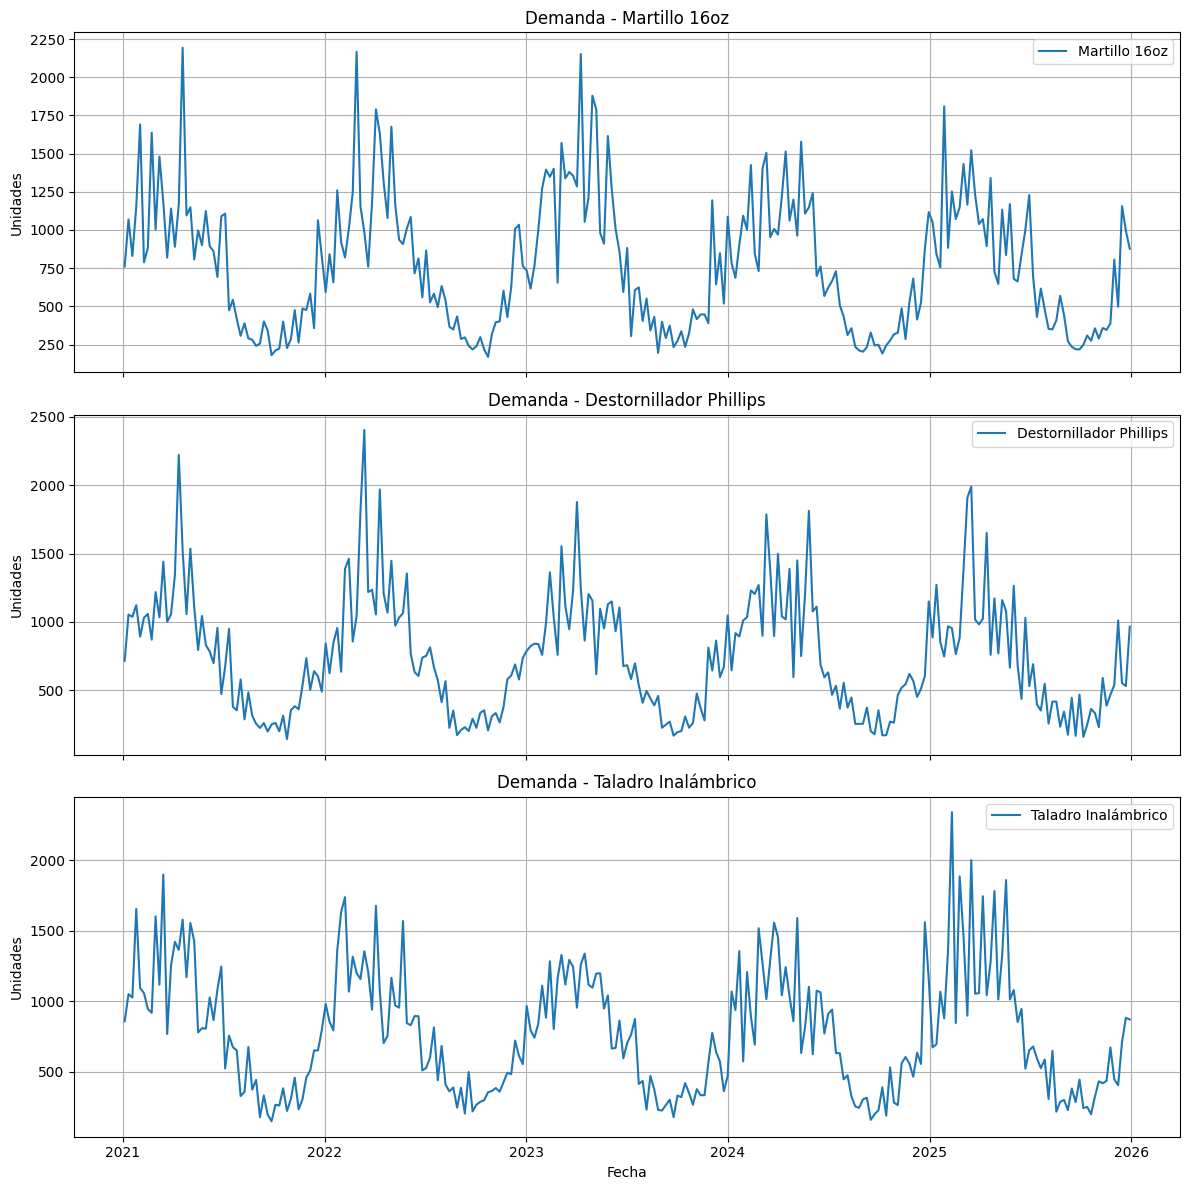

In [40]:
import matplotlib.pyplot as plt

def plot_multiple_sku_demand(df, n_skus, date_col="ds", demand_col="demand_units", id_col="sku_id"):
    """
    Grafica la demanda de varios SKU en subplots.
    
    Parámetros:
    df : DataFrame con columnas [id_col, date_col, demand_col]
    n_skus : número de SKU a graficar (se seleccionan los primeros n_skus únicos)
    date_col : columna de fechas (por defecto 'ds')
    demand_col : columna de demanda (por defecto 'demand_units')
    id_col : columna identificadora del SKU (por defecto 'sku_id')
    """
    # Seleccionar los primeros n_skus
    sku_list = df[id_col].unique()[:n_skus]
    
    # Crear subplots
    fig, axes = plt.subplots(n_skus, 1, figsize=(12, 4*n_skus), sharex=True)
    
    # Si solo hay un SKU, axes no es lista → convertirlo
    if n_skus == 1:
        axes = [axes]
    
    for i, sku in enumerate(sku_list):
        sku_data = df[df[id_col] == sku]
        axes[i].plot(sku_data[date_col], sku_data[demand_col], label=f"{sku}", color="tab:blue")
        axes[i].set_title(f"Demanda - {sku}")
        axes[i].set_ylabel("Unidades")
        axes[i].legend()
        axes[i].grid(True)
    
    plt.xlabel("Fecha")
    plt.tight_layout()
    plt.show()


# Graficar los primeros 3 SKU en subplots
plot_multiple_sku_demand(df, n_skus=3)


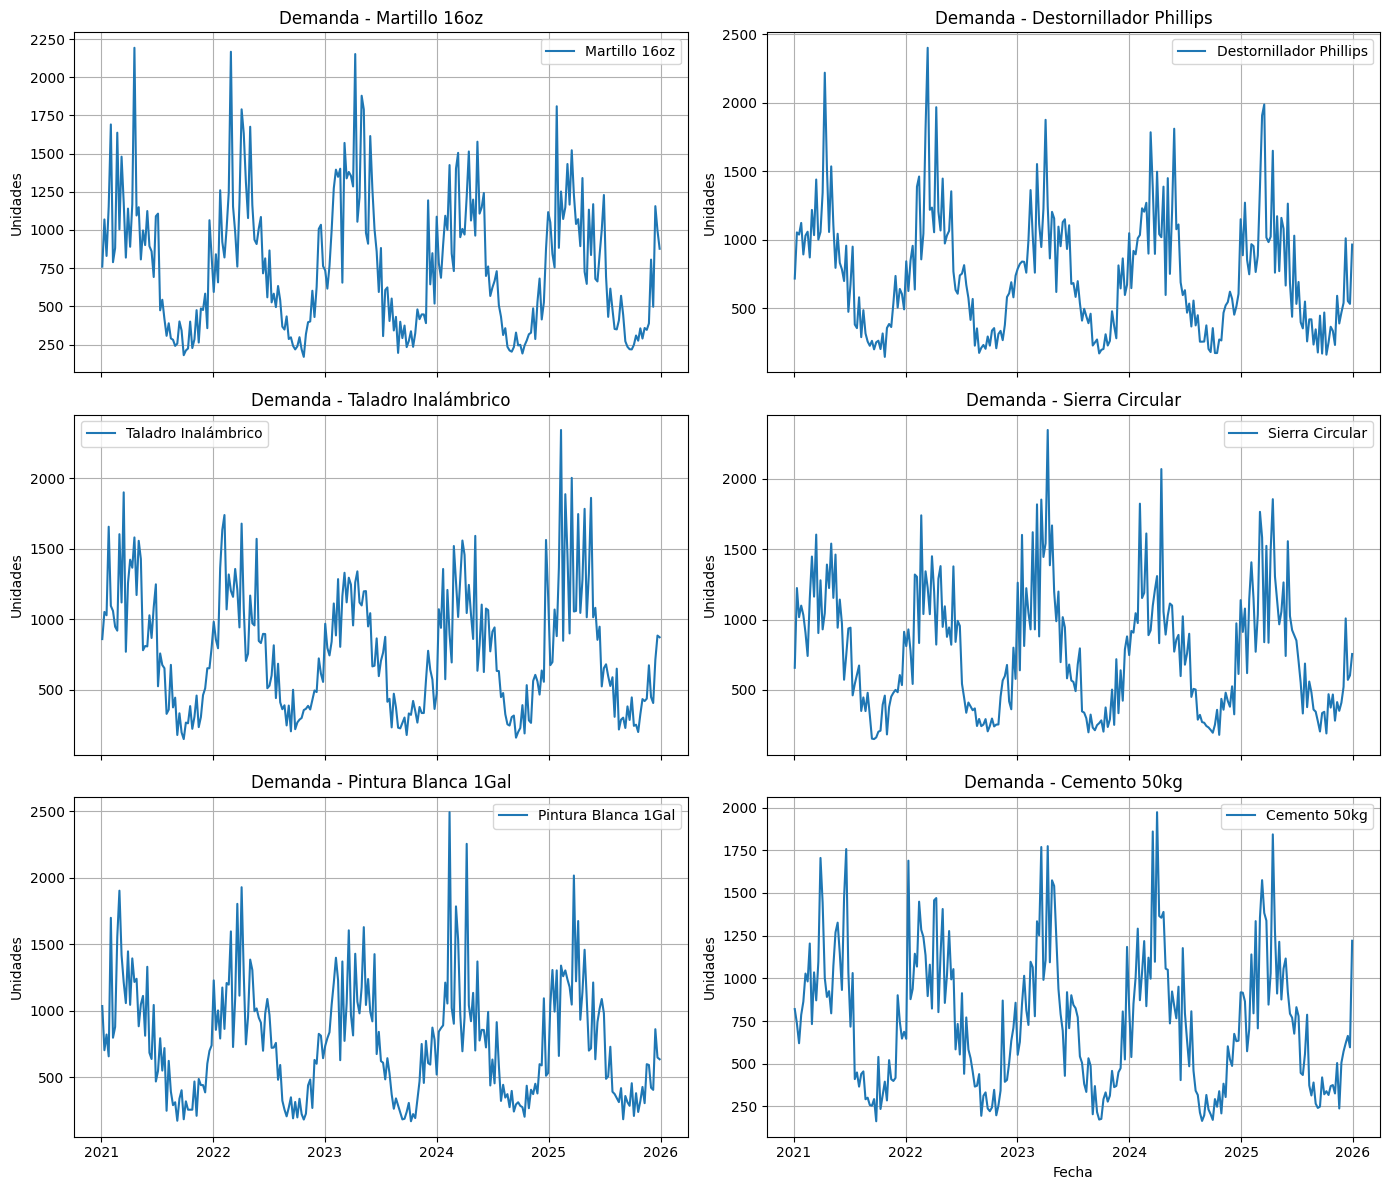

In [41]:
import matplotlib.pyplot as plt
import math

def plot_multiple_sku_demand(df, n_skus, date_col="ds", demand_col="demand_units", id_col="sku_id", n_cols=2):
    """
    Grafica la demanda de varios SKU en subplots organizados en columnas.

    Parámetros:
    df : DataFrame con columnas [id_col, date_col, demand_col]
    n_skus : número de SKU a graficar (se seleccionan los primeros n_skus únicos)
    date_col : columna de fechas (por defecto 'ds')
    demand_col : columna de demanda (por defecto 'demand_units')
    id_col : columna identificadora del SKU (por defecto 'sku_id')
    n_cols : número de columnas de subplots (por defecto 2)
    """
    # Seleccionar los primeros n_skus
    sku_list = df[id_col].unique()[:n_skus]

    # Calcular número de filas necesarias
    n_rows = math.ceil(n_skus / n_cols)

    # Crear subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows), sharex=True)
    axes = axes.flatten()  # convertir a lista plana

    for i, sku in enumerate(sku_list):
        sku_data = df[df[id_col] == sku]
        axes[i].plot(sku_data[date_col], sku_data[demand_col], label=f"{sku}", color="tab:blue")
        axes[i].set_title(f"Demanda - {sku}")
        axes[i].set_ylabel("Unidades")
        axes[i].legend()
        axes[i].grid(True)

    # Eliminar subplots vacíos si sobran
    for j in range(len(sku_list), len(axes)):
        fig.delaxes(axes[j])

    plt.xlabel("Fecha")
    plt.tight_layout()
    plt.show()


# Graficar los primeros 6 SKU en subplots con 2 columnas
plot_multiple_sku_demand(df, n_skus=6, n_cols=2)


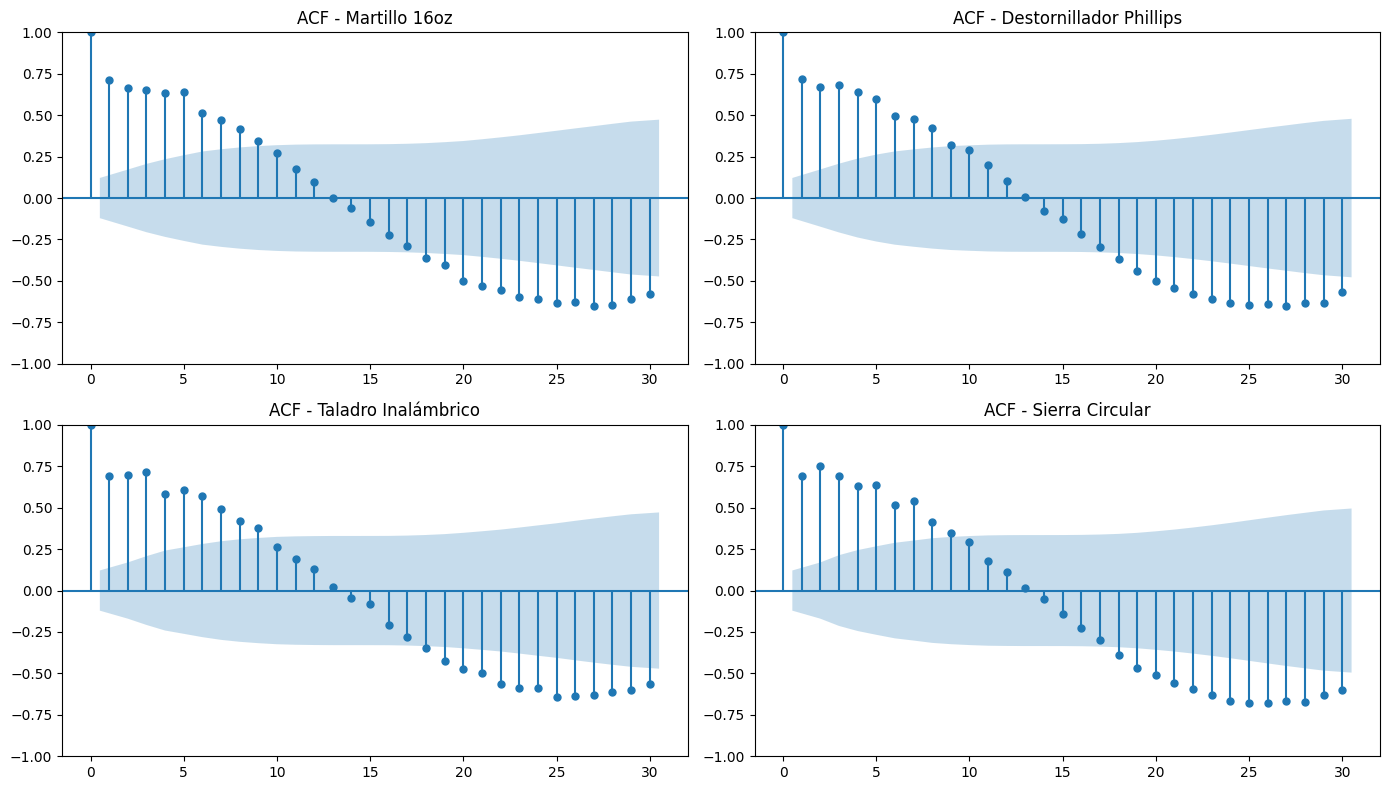

In [42]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import math

def plot_multiple_sku_acf(df, n_skus, lags, demand_col="demand_units", id_col="sku_id", n_cols=2):
    """
    Grafica el ACF de varios SKU en subplots organizados en columnas.

    Parámetros:
    df : DataFrame con columnas [id_col, demand_col]
    n_skus : número de SKU a graficar (se seleccionan los primeros n_skus únicos)
    lags : número de rezagos (lags) para el ACF
    demand_col : columna de demanda (por defecto 'demand_units')
    id_col : columna identificadora del SKU (por defecto 'sku_id')
    n_cols : número de columnas de subplots (por defecto 2)
    """
    # Seleccionar los primeros n_skus
    sku_list = df[id_col].unique()[:n_skus]

    # Calcular número de filas necesarias
    n_rows = math.ceil(n_skus / n_cols)

    # Crear subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten()

    for i, sku in enumerate(sku_list):
        series = df[df[id_col] == sku][demand_col].dropna()
        plot_acf(series, lags=lags, ax=axes[i])
        axes[i].set_title(f"ACF - {sku}")

    # Eliminar subplots vacíos si sobran
    for j in range(len(sku_list), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# Graficar el ACF de los primeros 4 SKU con 30 lags en subplots de 2 columnas
plot_multiple_sku_acf(df, n_skus=4, lags=30, n_cols=2)


In [43]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

def adf_test_per_sku(df, value_col, id_col="unique_id"):
    """
    Ejecuta la prueba de Dickey-Fuller aumentada para cada SKU
    y guarda los resultados en un DataFrame.

    Parámetros:
    df : DataFrame con columnas [id_col, value_col]
    value_col : nombre de la columna con la serie temporal
    id_col : identificador del SKU (por defecto 'unique_id')

    Retorna:
    results_df : DataFrame con resultados de la prueba por SKU
    """
    results = []

    for sku in df[id_col].unique():
        series = df.loc[df[id_col] == sku, value_col].dropna()

        dftest = adfuller(series, autolag='AIC')
        result_dict = {
            "SKU": sku,
            "Test Statistic": dftest[0],
            "p-value": dftest[1],
            "No Lags Used": dftest[2],
            "Número de observaciones utilizadas": dftest[3],
        }
        # Valores críticos
        for key, value in dftest[4].items():
            result_dict[f"Critical Value {key}"] = value

        # Conclusión
        if dftest[1] <= 0.05:
            result_dict["Conclusion"] = "Estacionaria (rechaza H0)"
        else:
            result_dict["Conclusion"] = "No estacionaria (no rechaza H0)"

        results.append(result_dict)

    results_df = pd.DataFrame(results)
    return results_df


In [47]:
df.columns

Index(['Unnamed: 0', 'sku_id', 'ds', 'price_unit', 'promotion_active',
       'season_factor', 'temperature_avg', 'rain_days', 'events_nearby',
       'marketing_spend', 'competitor_price', 'economic_index',
       'inflation_rate', 'construction_index', 'online_sales_rate',
       'store_visits', 'holiday_week', 'new_product_launch', 'lead_time_days',
       'current_stock', 'supplier_delay_rate', 'customer_reviews_score',
       'distribution_channels', 'previous_sku', 'demand_units'],
      dtype='str')

In [49]:
df_results = adf_test_per_sku(df, value_col= 'demand_units', id_col = 'sku_id',)
df_results


,SKU,Test Statistic,p-value,No Lags Used,Número de observaciones utilizadas,Critical Value 1%,Critical Value 5%,Critical Value 10%,Conclusion
0,Martillo 16oz,-7.231217,1.992359e-10,15,245,-3.457326,-2.873410,-2.573096,Estacionaria (rechaza H0)
1,Destornillador Phillips,-6.734492,3.233295e-09,16,244,-3.457438,-2.873459,-2.573122,Estacionaria (rechaza H0)
2,Taladro Inalámbrico,-6.796228,2.297289e-09,16,244,-3.457438,-2.873459,-2.573122,Estacionaria (rechaza H0)
3,Sierra Circular,-6.777278,2.551771e-09,16,244,-3.457438,-2.873459,-2.573122,Estacionaria (rechaza H0)
4,Pintura Blanca 1Gal,-7.487369,4.601064e-11,16,244,-3.457438,-2.873459,-2.573122,Estacionaria (rechaza H0)
5,Cemento 50kg,-6.240902,4.700055e-08,16,244,-3.457438,-2.873459,-2.573122,Estacionaria (rechaza H0)
6,"Tornillos 2""",-7.017783,6.663360e-10,16,244,-3.457438,-2.873459,-2.573122,Estacionaria (rechaza H0)
7,"Clavos 3""",-6.601458,6.719521e-09,15,245,-3.457326,-2.873410,-2.573096,Estacionaria (rechaza H0)
8,Cinta Métrica 5m,-6.401473,1.990604e-08,15,245,-3.457326,-2.873410,-2.573096,Estacionaria (rechaza H0)
9,Nivel 1m,-5.895147,2.863064e-07,16,244,-3.457438,-2.873459,-2.573122,Estacionaria (rechaza H0)


In [ ]:
df.columns